In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import torch.utils.data
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import random_split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

In [ ]:
#audio_path = "./dataset/audio_features.csv"
#lb_path = "./dataset/leader_board.csv"

audio_path = "./Hot 100 Audio Features.csv"
lb_path = "./Hot Stuff.csv"

audio = pd.read_csv(audio_path)
lb = pd.read_csv(lb_path)

In [ ]:
lb_song = (
    lb.groupby("SongID", as_index=False).agg(
        peak_position=("Peak Position", "min"),
        weeks_on_chart=("Weeks on Chart", "max")
    )
    .assign(hit=lambda d: (
        (d.peak_position <= 10) & (d.weeks_on_chart >= 10)
    ).astype(int))
)

lb_song.head()

,SongID,peak_position,weeks_on_chart,hit
0,"""B"" GirlsYoung And Restless",54,15,0
1,"""Cherry Cherry"" from Hot August NightNeil Diamond",31,10,0
2,"""Having A Party"" MedleyThe Ovations (Featuring...",56,9,0
3,"""Joy"" Pt. IIsaac Hayes",30,9,0
4,"""Roots"" MedleyQuincy Jones",57,7,0


`lb_song["hit"].mean()` returns that about 16.5% of songs are hits.

In [ ]:
df = audio.merge(lb_song, on="SongID", how="inner")

df.head()
# df[["spotify_genre", "spotify_track_duration_ms", "spotify_track_explicit", "spotify_track_album", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "time_signature", "danceability", "energy"]].isnull().mean()

,index,SongID,Performer,Song,spotify_genre,spotify_track_id,spotify_track_preview_url,spotify_track_duration_ms,spotify_track_explicit,spotify_track_album,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,spotify_track_popularity,peak_position,weeks_on_chart,hit
0,0,-twistin'-White Silver SandsBill Black's Combo,Bill Black's Combo,-twistin'-White Silver Sands,[],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92,2,0
1,1,¿Dònde Està Santa Claus? (Where Is Santa Claus...,Augie Rios,¿Dònde Està Santa Claus? (Where Is Santa Claus?),['novelty'],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47,4,0
2,2,......And Roses And RosesAndy Williams,Andy Williams,......And Roses And Roses,"['adult standards', 'brill building pop', 'eas...",3tvqPPpXyIgKrm4PR9HCf0,https://p.scdn.co/mp3-preview/cef4883cfd1e0e53...,166106.0,False,The Essential Andy Williams,...,0.91100,0.000267,0.112,0.150,83.969,4.0,38.0,36,7,0
3,3,...And Then There Were DrumsSandy Nelson,Sandy Nelson,...And Then There Were Drums,"['rock-and-roll', 'space age pop', 'surf music']",1fHHq3qHU8wpRKHzhojZ4a,NaN,172066.0,False,Compelling Percussion,...,0.00256,0.745000,0.145,0.801,121.962,4.0,11.0,65,4,0
4,4,...Baby One More TimeBritney Spears,Britney Spears,...Baby One More Time,"['dance pop', 'pop', 'post-teen pop']",3MjUtNVVq3C8Fn0MP3zhXa,https://p.scdn.co/mp3-preview/da2134a161f1cb34...,211066.0,False,...Baby One More Time (Digital Deluxe Version),...,0.20200,0.000131,0.443,0.907,92.960,4.0,77.0,1,32,1


# Defining our outcome variable:

Given that out dataset contains only songs in the Billboard Hot 100, the outcome variable must be able to distinguish between varying degrees of popularity rather than simple chart entry. We consider two principled approaches for defining hit status.

### Option 1: Composite Popularity Score
One approach is to construct a composite popularity measure that incorporates both a song's `Peak Position` and its `Weeks on Chart`. Peak position captures the maximum intensity of popularity and weeks on chart reflects sustained audience engagement. This approach is a simple and straight forward definiton of defining success. It captures both short-term impact and longevity but introduces additional modeling assumptions.

Song is defined as a hit if:
    
(`Peak Position` $\leq$ 10) AND (`Weeks on Chart` $\geq$ 10)

### Option 2: Threshold-Based Hit Categories
Another approach defines hit status based solely on `Peak Position` thresholds. Under this framework, songs can be categorized as:
- Top 10 Hit: Peak Position $\leq$ 10

- Major Hit: Peak Position $\leq$ 5

- #1 Hit: Peak Position = 1

# Baseline Logistic Regression Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
#define target
y = df["hit"].astype(int)


In [ ]:
df["spotify_track_explicit"].head(20)
#df["spotify_track_explicit"].astype(str).value_counts().head(20)



,spotify_track_explicit
0,0
1,0
2,0
3,0
4,0
5,0
6,1
7,0
8,0
9,0


In [ ]:
audio["spotify_track_explicit"].value_counts(dropna=False).head(10)




,count
spotify_track_explicit,
False,21449
NaN,5106
True,2948


In [ ]:
#convert explicit to numeric
df["spotify_track_explicit"] = df["spotify_track_explicit"].map(
    {True: 1, False: 0}
)




In [ ]:
#audio features only
explicit_map = (
    audio[["SongID", "spotify_track_explicit"]]
    .drop_duplicates("SongID")
    .set_index("SongID")["spotify_track_explicit"]
)

df["spotify_track_explicit"] = df["SongID"].map(explicit_map)

df["spotify_track_explicit"] = (
    df["spotify_track_explicit"]
    .map({True: 1, False: 0})
    .fillna(0)
    .astype(int)
)


feature_cols = [
    "spotify_track_duration_ms",
    "spotify_track_explicit",
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "time_signature"
]

X = df[feature_cols]
y = df["hit"].astype(int)

df["spotify_track_explicit"].value_counts(dropna=False)

,count
spotify_track_explicit,
0,26552
1,2948


In [ ]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
#build, train model
clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

clf.fit(X_train, y_train)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [ ]:
#eval
y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

print("Hit Rate:", y.mean())
print("AUROC:", roc_auc_score(y_test, y_prob))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Hit Rate: 0.1654915254237288
AUROC: 0.587580818606757
Accuracy: 0.6413559322033898
Confusion Matrix:
 [[3283 1641]
 [ 475  501]]


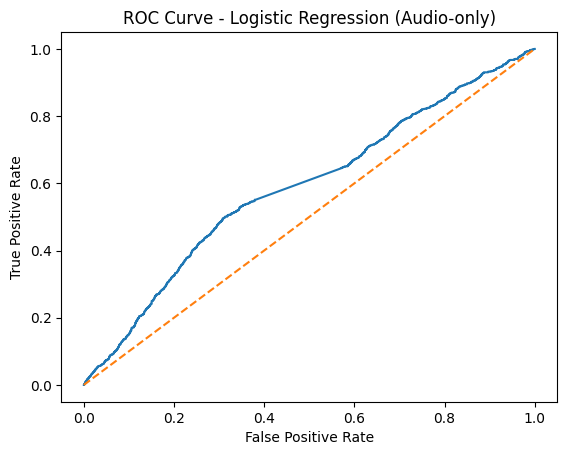

In [ ]:
#roc curv
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Audio-only)")
plt.show()


In [ ]:
coefs = clf.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_cols, "coef": coefs}).sort_values("coef", ascending=False)
coef_df



,feature,coef
0,spotify_track_duration_ms,0.153220
2,danceability,0.146899
11,valence,0.103100
8,acousticness,0.081138
13,time_signature,0.031592
12,tempo,0.008195
5,loudness,0.007765
9,instrumentalness,-0.016142
10,liveness,-0.017886
7,speechiness,-0.022709
